In [ ]:
import pandas as pd
df=pd.read_excel('loan3(na).xlsx')

In [ ]:
df.head()

,loan,Industry_type,Company_type,Beginning_time,Collateral,Bank_relationship,Capital_increase,Age,Education,Credit
0,1.0,1,1.0,4,4,1,4,3,2,2
1,1.0,2,1.0,2,3,2,3,4,3,2
2,1.0,1,1.0,3,3,1,4,3,4,1
3,1.0,2,1.0,4,1,1,4,3,4,2
4,1.0,1,1.0,3,1,1,3,2,3,2


In [ ]:
df1=df.dropna()
X=df1[['Industry_type','Company_type','Beginning_time','Bank_relationship','Capital_increase','Age','Education','Credit']]
y=df1['loan'] 
from sklearn.model_selection import train_test_split #區分訓練集與測試集
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5) 

## **一、分類器(Decision Tree and Random Forest)**

# **決策樹(Decision Tree)**

In [ ]:
#以決策樹建立預測模型
from sklearn import tree
DT = tree.DecisionTreeClassifier()
DT= DT.fit(X, y)

In [ ]:
#列出各特徵重要程度
print('特徵重要程度: ',DT.feature_importances_)

特徵重要程度:  [0.0830161  0.06190314 0.069756   0.03920336 0.07842394 0.11283694
 0.09819541 0.45666511]


In [ ]:
#評估決策樹訓練集預測結果的混淆矩陣/精準度、召回率、F1
DT_pred= DT.predict(X_train)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_train,DT_pred))
print("======================================================\n")
print(classification_report(y_train,DT_pred))

[[123   1]
 [  4  35]]

              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98       124
         2.0       0.97      0.90      0.93        39

    accuracy                           0.97       163
   macro avg       0.97      0.94      0.96       163
weighted avg       0.97      0.97      0.97       163



In [ ]:
#評估決策樹測試集預測結果的混淆矩陣/精準度、召回率、F1
DT_pred= DT.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,DT_pred))
print("======================================================\n")
print(classification_report(y_test,DT_pred))

[[28  0]
 [ 0 13]]

              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00        28
         2.0       1.00      1.00      1.00        13

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



[Text(127.95637500000001, 208.38, 'X[7] <= 1.5\ngini = 0.38\nsamples = 204\nvalue = [152, 52]'),
 Text(50.220000000000006, 190.26, 'X[0] <= 1.5\ngini = 0.289\nsamples = 40\nvalue = [7, 33]'),
 Text(26.784000000000002, 172.14, 'X[5] <= 2.5\ngini = 0.494\nsamples = 9\nvalue = [5, 4]'),
 Text(13.392000000000001, 154.01999999999998, 'X[2] <= 2.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(6.696000000000001, 135.89999999999998, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(20.088, 135.89999999999998, 'X[2] <= 3.5\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(13.392000000000001, 117.77999999999999, 'X[3] <= 1.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(6.696000000000001, 99.66, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(20.088, 99.66, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(26.784000000000002, 117.77999999999999, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(40.176, 154.01999999999998, 'X[2] <= 3.5\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 T

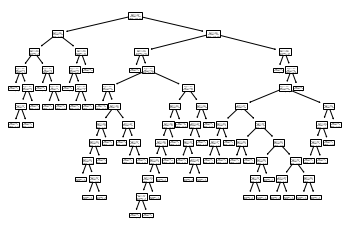

In [ ]:
#繪製決策樹圖型(黑白)
tree.plot_tree(DT)

In [ ]:
#儲存圖形(可於左側載入區下載圖形)
import graphviz 
dot_data = tree.export_graphviz(DT) 
graph = graphviz.Source(dot_data) 
graph.render("loan") 

'loan.pdf'

In [ ]:
#繪製決策樹圖形(彩色)
dot_data = tree.export_graphviz(DT,feature_names=['Industry_type','Company_type','Beginning_time','Bank_relationship','Capital_increase','Age','Education','Credit'],    
                      filled=True, rounded=True)  
graph = graphviz.Source(dot_data)  
graph 
graph.render("loan2") 

'loan2.pdf'

# 決策樹圖形
前述決策樹特徵多不易說明，改取較少特徵分析說明

In [ ]:
df2=df.dropna()
X=df2[['Industry_type','Bank_relationship','Age']]
y=df2['loan'] 
from sklearn.model_selection import train_test_split #區分訓練集與測試集
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5) 

In [ ]:
#以決策樹建立預測模型
from sklearn import tree
DT = tree.DecisionTreeClassifier()
DT= DT.fit(X, y)

In [ ]:
#評估決策樹測試集預測結果的混淆矩陣/精準度、召回率、F1
DT_pred= DT.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,DT_pred))
print("======================================================\n")
print(classification_report(y_test,DT_pred))

[[27  1]
 [ 5  8]]

              precision    recall  f1-score   support

         1.0       0.84      0.96      0.90        28
         2.0       0.89      0.62      0.73        13

    accuracy                           0.85        41
   macro avg       0.87      0.79      0.81        41
weighted avg       0.86      0.85      0.85        41



In [ ]:
#繪製決策樹圖形(彩色)
import graphviz 
dot_data = tree.export_graphviz(DT, out_file=None, 
                      feature_names=['Industry_type','Bank_relationship','Age'],    
                      filled=True, rounded=True)  
graph = graphviz.Source(dot_data)  
graph 
graph.render("loan3") 

'loan3.pdf'

# **隨機森林(Random Forest)**

In [ ]:
df1=df.dropna()
X=df1[['Industry_type','Company_type','Beginning_time','Bank_relationship','Capital_increase','Age','Education','Credit']]
y=df1['loan'] 
from sklearn.model_selection import train_test_split #區分訓練集與測試集
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=5) 

In [ ]:
#使用隨機森林進行機器學習模型
from sklearn.ensemble import RandomForestClassifier

#n_estimator代表要最高使用多少棵樹
RF = RandomForestClassifier(n_estimators=50,max_features="sqrt",oob_score=True,random_state=3)

#從訓練組資料中建立隨機森林模型
RF.fit(X_train,y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:446: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  "X does not have valid feature names, but"


RandomForestClassifier(max_features='sqrt', n_estimators=50, oob_score=True,
                       random_state=3)

In [ ]:
#列出各特徵重要程度
print('特徵重要程度: ',RF.feature_importances_)
print('oob score: ',RF.oob_score_)

特徵重要程度:  [0.08233906 0.05538    0.14564975 0.08355359 0.07999366 0.16157354
 0.109406   0.2821044 ]
oob score:  0.8404907975460123


In [ ]:
#評估隨機森林訓練集預測結果的精準度、召回率、F1
RF_pred= RF.predict(X_train)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_train,RF_pred))
print("======================================================\n")
print(classification_report(y_train,RF_pred))

[[123   1]
 [  4  35]]

              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98       124
         2.0       0.97      0.90      0.93        39

    accuracy                           0.97       163
   macro avg       0.97      0.94      0.96       163
weighted avg       0.97      0.97      0.97       163



In [ ]:
#評估隨機森林測試集預測結果的精準度、召回率、F1
RF_pred= RF.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,RF_pred))
print("======================================================\n")
print(classification_report(y_test,RF_pred))

[[27  1]
 [ 5  8]]

              precision    recall  f1-score   support

         1.0       0.84      0.96      0.90        28
         2.0       0.89      0.62      0.73        13

    accuracy                           0.85        41
   macro avg       0.87      0.79      0.81        41
weighted avg       0.86      0.85      0.85        41



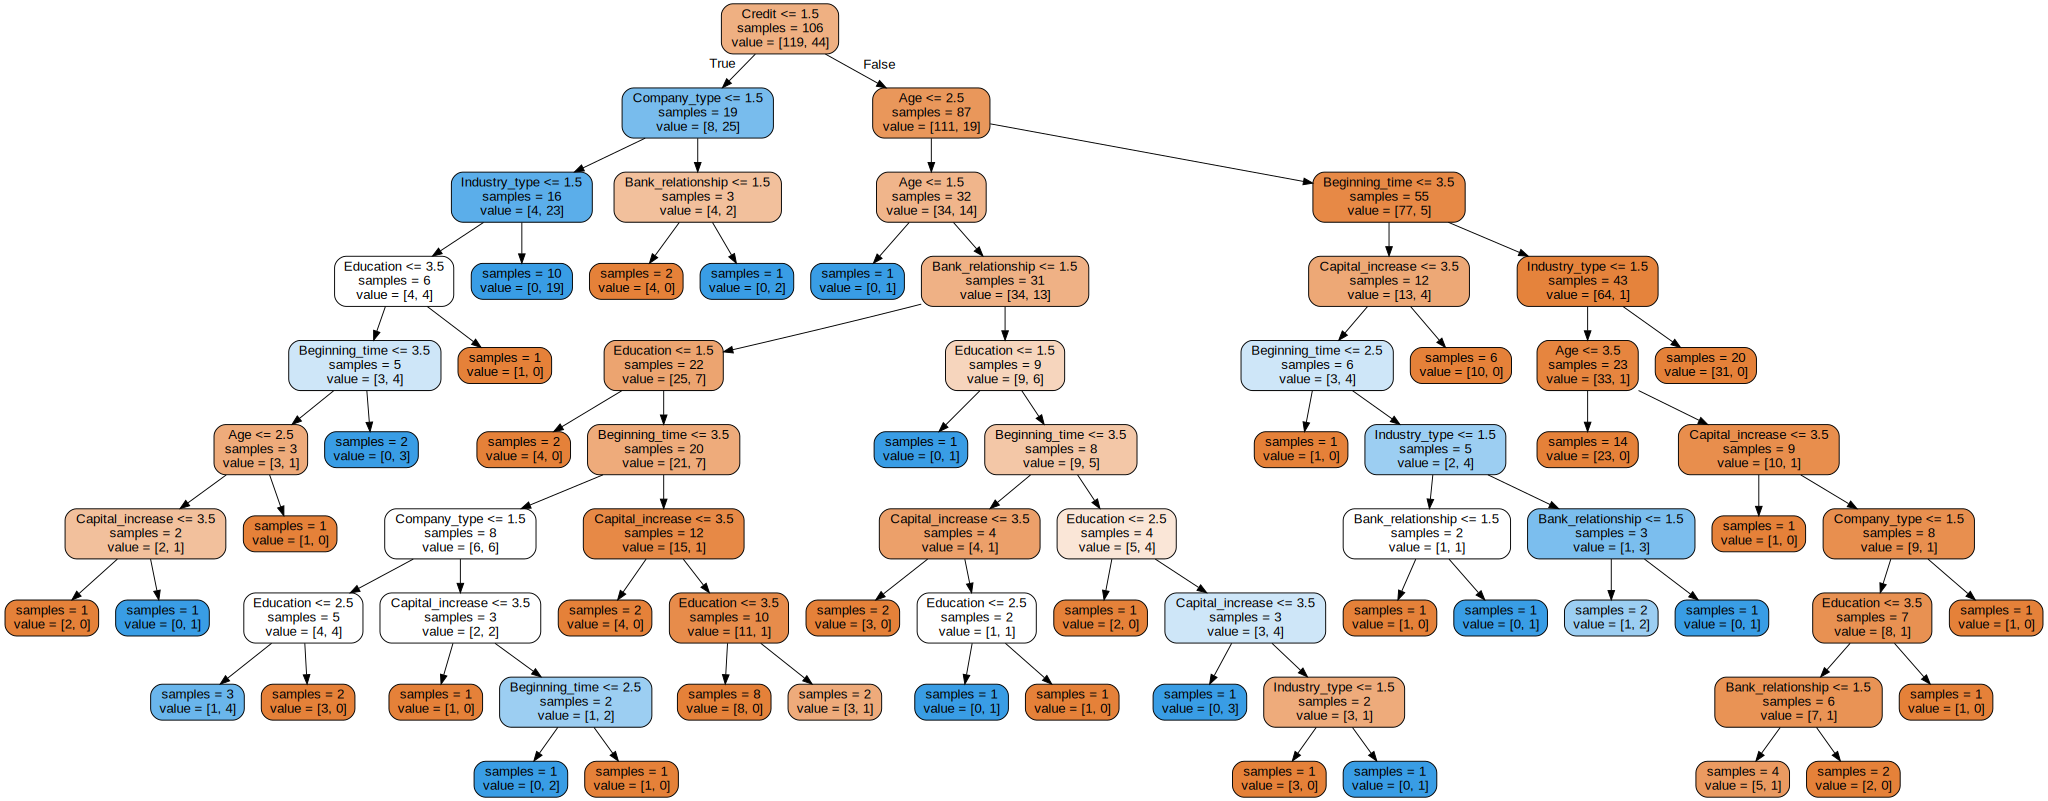

In [ ]:
# 將分析結果以視覺化圖形呈現(僅可取其中一棵樹繪圖)
from sklearn import tree #導入決策樹模組
import graphviz #導入可視化模組
dot_df = \
    tree.export_graphviz(
            RF.estimators_[30], 
            out_file = None,
            feature_names=['Industry_type','Company_type','Beginning_time','Bank_relationship','Capital_increase','Age','Education','Credit'],
            filled = True,
            impurity = False,
            rounded = True)

graph=graphviz.Source(dot_df) #將分析結果以graphviz圖檔呈現
graph
#graph.render("loan4") #下載唯讀圖檔

# **二、“量”的預測模式(迴歸)：Decision Tree and Random Forest**

# **決策樹(Decision Tree)**

In [ ]:
import pandas as pd
df = pd.DataFrame({'Q1': [2, 3, 5, 3, 6, 2, 7, 8, 6, 4],
                   'Q2': [12, 15, 21, 16, 29, 11, 33, 40, 30, 18]})

In [ ]:
X=df[['Q1']]
y=df[['Q2']] 

In [ ]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=0)
regressor.fit(X, y)

DecisionTreeRegressor(random_state=0)

In [ ]:
dot_data = tree.export_graphviz(regressor,feature_names=['Q1'],    
                      filled=True, rounded=True)  
graph = graphviz.Source(dot_data)  
graph 
graph.render("test") 

'test.pdf'

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
# 使用X_test預測y，得到y_pred1 
y_pred1 = regressor.predict(X)
rmse = sqrt(mean_squared_error(y, y_pred1)) 
print("rmse: %.3f" % rmse) 

rmse: 0.387


# **隨機森林(Random Forest)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 建立RandomForestRegressor模型
RF2 = RandomForestRegressor(n_estimators=3, criterion = 'mse')
# 使用訓練資料訓練模型
RF2.fit(X, y)
# 使用訓練資料預測
predicted=RF2.predict(X)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  
/usr/local/lib/python3.7/dist-packages/sklearn/ensemble/_forest.py:392: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  FutureWarning,


In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
# 使用X_test預測y，得到y_pred1 
y_pred1 = RF2.predict(X)
rmse = sqrt(mean_squared_error(y, y_pred1)) 
print("rmse: %.3f" % rmse) 

rmse: 1.053


# 練習
1.請以salary.xlsx檔案資料的工作年資、教育年資與性別等特徵建立決策樹與隨機森林預測模式，預測年所得高於50或低於50（萬元）。(分類器：類別預測),分析後請畫出決策樹，並說明模式之判定準則。

2.請以salary.xlsx檔案資料的工作年資、教育年資與性別等特徵建立決策樹與隨機森林預測模式，預測年所得。(迴歸器：量的預測)，分析後請畫出決策樹，並說明模式之判定準則。



# 作業(決策樹)：
(1)請利用boston_house(type).xlsx檔案中的指標，以決策樹來預測boston house的房價高低(Price Type)，分析後請畫出決策樹，並說明決策樹之主要判定準則。

(2)請利用boston_house(type).xlsx檔案中的指標，以決策樹來預測boston house的房價(Price)，分析後請畫出決策樹，並說明決策樹之主要判定準則。

註： 1.資料與預測指標說明如附檔。 2.Price Type:1表單位房價低於20，2表單位房價高於20。

# 作業(隨機森林)：
(1)請利用boston_house(type).xlsx檔案中的指標，以隨機森林來預測boston house的房價高低(Price Type)，分析後請說明隨機森林之主要判定準則及預測準確度。

(2)請利用boston_house(type).xlsx檔案中的指標，以隨機森林來預測boston house的房價(Price)，分析後請說明隨機森林之主要判定準則及預測準確度。

註： 1.資料與預測指標說明如附檔。 2.Price Type:1表單位房價低於20，2表單位房價高於20。